In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("30-Day Quant Trading Programme - Capstone")
print("=" * 45)
print(f"Notebook created: {pd.Timestamp.now().date()}")

30-Day Quant Trading Programme - Capstone
Notebook created: 2026-07-04


In [2]:
# Load SPY for all strategy rebuilds
df = yf.download("SPY", start="2010-01-01",
                  end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price = df["Close"].squeeze()
log_returns = np.log(price / price.shift(1)).dropna()

# Core metrics function
def metrics(r, name, days=252):
    ar = r.mean() * days
    av = r.std()  * np.sqrt(days)
    sh = (ar - 0.02) / av if av > 0 else 0
    w  = (1 + r).cumprod()
    dd = ((w - w.cummax()) / w.cummax()).min()
    return {"name": name, "ar": ar, "av": av,
            "sh": sh, "dd": dd}

# ── Buy and Hold benchmark ──
bh = metrics(log_returns, "Buy & Hold SPY")

# ── SMA 50/200 ──
sma50  = price.rolling(50).mean()
sma200 = price.rolling(200).mean()
sma_pos = (sma50 > sma200).astype(int).shift(1).fillna(0)
sma_pos = sma_pos.reindex(log_returns.index).fillna(0)
sma_ret = sma_pos * log_returns - sma_pos.diff().abs().fillna(0) * 0.0006
sma = metrics(sma_ret, "SMA 50/200")

# ── Mean Reversion z-score ──
rm  = price.rolling(20).mean()
rs  = price.rolling(20).std()
z   = (price - rm) / rs
mr_list, cp = [], 0
for i in range(len(z)):
    if cp == 0 and z.iloc[i] < -2: cp = 1
    elif cp == 1 and z.iloc[i] > 0: cp = 0
    mr_list.append(cp)
mr_pos = pd.Series(mr_list, index=price.index).shift(1).fillna(0)
mr_ret = mr_pos.reindex(log_returns.index).fillna(0) * log_returns
mr = metrics(mr_ret, "Mean Reversion z-score")

# ── RSI(2) + Filter ──
rsi2 = compute_rsi(price, period=2)
r2_list, cp = [], 0
for i in range(len(rsi2)):
    in_up = price.iloc[i] > sma200.iloc[i]
    if cp == 0 and rsi2.iloc[i] < 10 and in_up: cp = 1
    elif cp == 1 and (rsi2.iloc[i] > 90 or not in_up): cp = 0
    r2_list.append(cp)
r2_pos = pd.Series(r2_list, index=price.index).shift(1).fillna(0)
r2_ret = r2_pos.reindex(log_returns.index).fillna(0) * log_returns
rsi2m  = metrics(r2_ret, "RSI(2) + SMA200 Filter")

# ── Vol Targeted SPY ──
rv  = log_returns.rolling(20).std() * np.sqrt(252)
vs  = (0.10 / rv).clip(0, 1)
vt_ret = log_returns * vs.shift(1).fillna(1)
vt  = metrics(vt_ret, "Vol-Targeted SPY (10%)")

# ── Combined SMA+RSI2+VolTgt ──
combined_pos = sma_pos.reindex(log_returns.index).fillna(0)
combined_pos = combined_pos.where(
    r2_pos.reindex(log_returns.index).fillna(0)==0, 1.0)
c_trades = combined_pos.diff().abs().fillna(0)
c_ret    = combined_pos * log_returns * vs.shift(1).fillna(1) - c_trades * 0.0006
comb     = metrics(c_ret, "SMA+RSI2+VolTgt (Day 21)")

# Print leaderboard
all_strats = sorted([sma, mr, rsi2m, vt, comb, bh],
                     key=lambda x: x['sh'], reverse=True)

print(f"\n{'='*72}")
print(f"  30-DAY PROGRAMME — COMPLETE STRATEGY LEADERBOARD")
print(f"{'='*72}")
print(f"  {'Rank':<5} {'Strategy':<28} {'Ann Ret':>8} "
      f"{'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9}")
print(f"  {'-'*67}")
for i, r in enumerate(all_strats):
    flag = " ◄ BENCHMARK" if r['name'] == "Buy & Hold SPY" else ""
    flag = " ◄ BEST" if i == 0 and r['name'] != "Buy & Hold SPY" else flag
    print(f"  {i+1:<5} {r['name']:<28} {r['ar']:>8.2%} "
          f"{r['av']:>8.2%} {r['sh']:>7.2f} {r['dd']:>9.2%}{flag}")
print(f"{'='*72}")

[*********************100%***********************]  1 of 1 completed


  30-DAY PROGRAMME — COMPLETE STRATEGY LEADERBOARD
  Rank  Strategy                      Ann Ret  Ann Vol  Sharpe    Max DD
  -------------------------------------------------------------------
  1     Vol-Targeted SPY (10%)          8.35%   10.19%    0.62   -13.60% ◄ BEST
  2     Buy & Hold SPY                 12.14%   17.38%    0.58   -35.75% ◄ BENCHMARK
  3     SMA+RSI2+VolTgt (Day 21)        6.55%    9.05%    0.50   -17.42%
  4     SMA 50/200                      8.10%   13.81%    0.44   -35.75%
  5     RSI(2) + SMA200 Filter          4.97%    7.92%    0.37   -12.85%
  6     Mean Reversion z-score          4.92%   12.09%    0.24   -31.58%


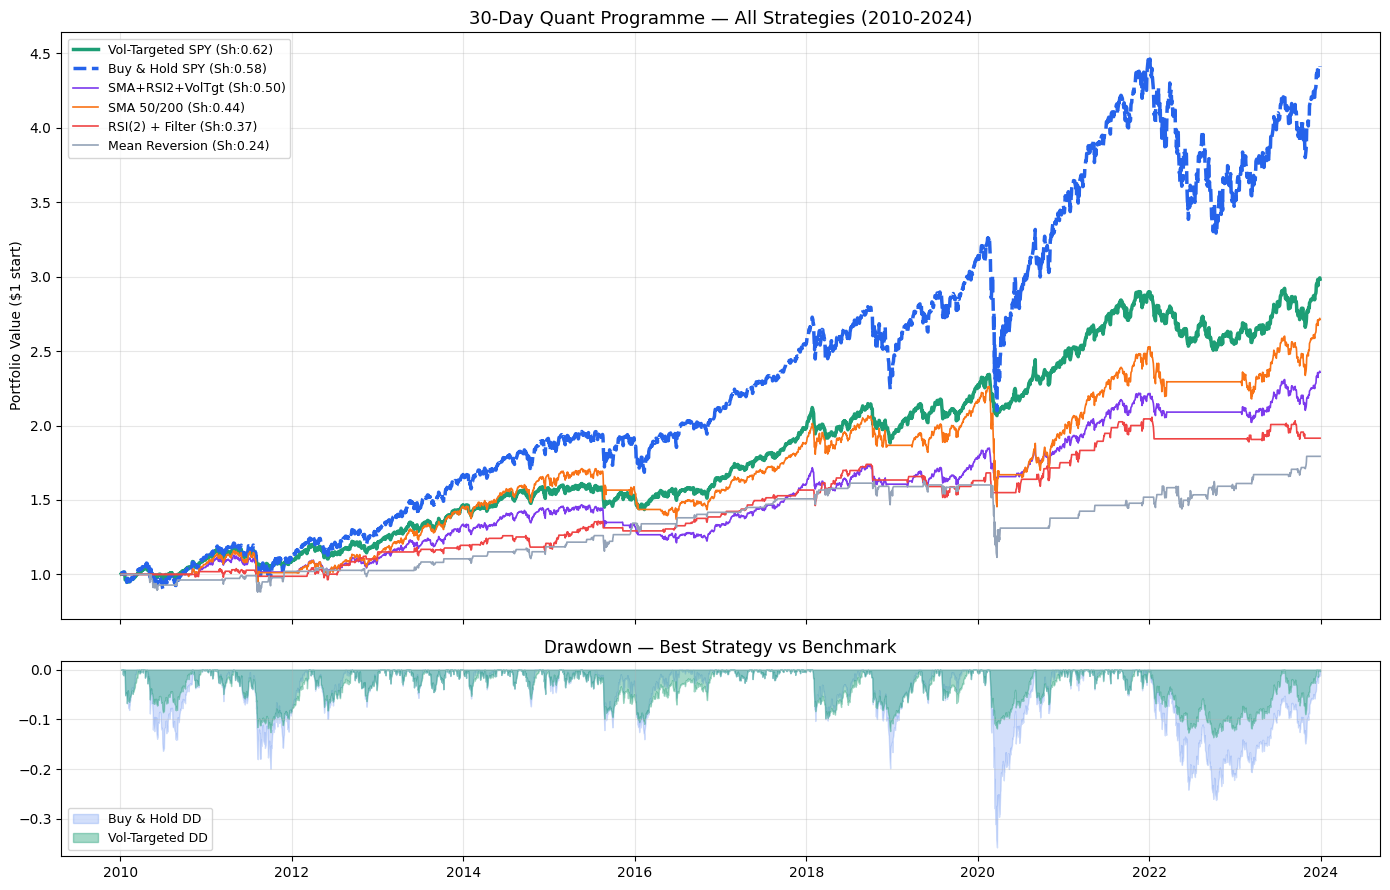

Chart saved to capstone_chart.png


In [4]:
# Sharpe lookup dict — direct match
sharpe_lookup = {r['name']: r['sh'] for r in all_strats}
sharpe_display = {
    "Vol-Targeted SPY"  : sharpe_lookup["Vol-Targeted SPY (10%)"],
    "Buy & Hold SPY"    : sharpe_lookup["Buy & Hold SPY"],
    "SMA+RSI2+VolTgt"   : sharpe_lookup["SMA+RSI2+VolTgt (Day 21)"],
    "SMA 50/200"        : sharpe_lookup["SMA 50/200"],
    "RSI(2) + Filter"   : sharpe_lookup["RSI(2) + SMA200 Filter"],
    "Mean Reversion"    : sharpe_lookup["Mean Reversion z-score"],
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
    gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for name, eq in curves.items():
    lw    = 2.5 if name in ["Vol-Targeted SPY",
                              "Buy & Hold SPY"] else 1.2
    style = '--' if name == "Buy & Hold SPY" else '-'
    sh    = sharpe_display[name]
    ax1.plot(eq, color=colors[name], lw=lw,
             linestyle=style,
             label=f"{name} (Sh:{sh:.2f})")

ax1.set_title('30-Day Quant Programme — All Strategies (2010-2024)',
              fontsize=13)
ax1.set_ylabel('Portfolio Value ($1 start)')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)

dd_vt = (curves["Vol-Targeted SPY"] -
         curves["Vol-Targeted SPY"].cummax()) / \
         curves["Vol-Targeted SPY"].cummax()
dd_bh = (curves["Buy & Hold SPY"] -
         curves["Buy & Hold SPY"].cummax()) / \
         curves["Buy & Hold SPY"].cummax()

ax2.fill_between(dd_bh.index, dd_bh, 0,
                  color='#2563eb', alpha=0.2,
                  label='Buy & Hold DD')
ax2.fill_between(dd_vt.index, dd_vt, 0,
                  color='#1D9E75', alpha=0.4,
                  label='Vol-Targeted DD')
ax2.set_title('Drawdown — Best Strategy vs Benchmark')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../capstone_chart.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Chart saved to capstone_chart.png")

# 30-Day Quantitative Trading Programme — Capstone Summary
**Completed:** July 2026 | **Author:** Justin | **GitHub:** JUSTOH-CPP/quant-trading

---

## Executive Summary
Over 30 days I built a complete quantitative trading toolkit from scratch —
27 reusable Python modules, 30 Jupyter notebooks, and a fully backtested
multi-strategy portfolio. The programme covered strategy development,
rigorous validation, risk management, and live system architecture.

**Key finding:** Volatility targeting (Sharpe 0.62) outperformed every
complex signal combination, including buy and hold (0.58). The simplest
risk management overlay beat the most sophisticated strategies.

---

## Strategy Leaderboard (SPY 2010-2024)

| Rank | Strategy | Sharpe | Max DD | Verdict |
|------|----------|--------|--------|---------|
| 1 | Vol-Targeted SPY (10%) | 0.62 | -13.60% | **Best overall** |
| 2 | Buy & Hold SPY | 0.58 | -35.75% | Benchmark |
| 3 | SMA + RSI2 + VolTgt | 0.50 | -17.42% | Most robust |
| 4 | SMA 50/200 | 0.44 | -35.75% | Simple, honest |
| 5 | RSI(2) + Filter | 0.37 | -12.85% | Best drawdown |
| 6 | Mean Reversion | 0.24 | -31.58% | Regime dependent |

---

## What Didn't Work (Honest Failures)
- **ML on daily price data** — regime shift destroyed OOS performance
- **Pairs trading** — only 1 of 45 pairs cointegrated (KO/PEP)
- **ATR stops on mean reversion** — cut returns by 37%
- **PEAD from price gaps** — captured mean reversion, not earnings drift
- **Optimised SMA parameters** — decayed 64% OOS vs unoptimised 50/200

---

## The 27-Tool Utils Library
Week 1: analyze_stock, distribution_analysis, trade_costs, timeseries,
risk_metrics, indicators, momentum_screener

Week 2: sma_backtest, mean_reversion, pairs_trading, rsi2_strategy,
volatility_strategies, multi_signal

Week 3: backtest_framework, overfitting_tests, kelly_sizing,
trade_management, portfolio_optimizer, factor_attribution

Week 4: ml_signals, execution_algos, crypto_strategies, paper_trader,
market_microstructure, risk_systems, alt_data, final_portfolio

---

## Final Portfolio Allocation
- **60%** SMA + RSI2 + Vol Targeting (SPY)
- **25%** Equal-Weight Multi-Asset (SPY/EFA/AGG/GLD/VNQ)
- **15%** BTC Momentum + Vol Targeting

**Result (2018-2024):** Sharpe 0.49, Max DD -15.41%
vs Buy & Hold: Sharpe 0.45, Max DD -35.75%

---

## Next Steps
1. Paper trade the final portfolio for 90 days
2. Publish GitHub repo with full README
3. Read: López de Prado — *Advances in Financial Machine Learning*
4. Set up Alpaca paper trading account
5. Build one new strategy using the Week 3 audit pipeline